**Decision trees with a toy task and the UCI Adult dataset**

In [1]:
import collections
from io import StringIO

import numpy as np
import pandas as pd
import pydotplus  # pip install pydotplus
import seaborn as sns
from ipywidgets import Image
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz

from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = (10, 8)

Part 1. Toy dataset “Will They? Won’t They?”

In [2]:
# creating dataframe using dummy variables

def create_df(dic, feature_list):
    out = pd.DataFrame(dic)
    out = pd.concat([out, pd.get_dummies(out[feature_list])], axis=1) # refer extranotes.ipynb
    out.drop(feature_list, axis=1, inplace=True)
    return out

In [3]:
# Some feature values are present in train and absent in test and vice-versa.
def intersect_features(train, test):
    common_feat = list(set(train.keys()) & set(test.keys()))  
    return train[common_feat], test[common_feat]

In [4]:
features = ["Looks", "Alcoholic_beverage", "Eloquence", "Money_spent"]

Training data

In [5]:
df_train = {}
df_train["Looks"] = [
    "handsome",
    "handsome",
    "handsome",
    "repulsive",
    "repulsive",
    "repulsive",
    "handsome",
]
df_train["Alcoholic_beverage"] = ["yes", "yes", "no", "no", "yes", "yes", "yes"]
df_train["Eloquence"] = ["high", "low", "average", "average", "low", "high", "average"]
df_train["Money_spent"] = ["lots", "little", "lots", "little", "lots", "lots", "lots"]
df_train["Will_go"] = LabelEncoder().fit_transform(["+", "-", "+", "-", "-", "+", "+"])

#print(df_train)

df_train = create_df(df_train, features)
df_train

,Will_go,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Eloquence_low,Money_spent_little,Money_spent_lots
0,0,True,False,False,True,False,True,False,False,True
1,1,True,False,False,True,False,False,True,True,False
2,0,True,False,True,False,True,False,False,False,True
3,1,False,True,True,False,True,False,False,True,False
4,1,False,True,False,True,False,False,True,False,True
5,0,False,True,False,True,False,True,False,False,True
6,0,True,False,False,True,True,False,False,False,True


Test data

In [6]:
df_test = {}
df_test["Looks"] = ["handsome", "handsome", "repulsive"]
df_test["Alcoholic_beverage"] = ["no", "yes", "yes"]
df_test["Eloquence"] = ["average", "high", "average"]
df_test["Money_spent"] = ["lots", "little", "lots"]
df_test = create_df(df_test, features)
df_test

,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Money_spent_little,Money_spent_lots
0,True,False,True,False,True,False,False,True
1,True,False,False,True,False,True,True,False
2,False,True,False,True,True,False,False,True


In [7]:
# Some feature values are present in train and absent in test and vice-versa.
y = df_train["Will_go"]
df_train, df_test = intersect_features(train=df_train, test=df_test)
df_train

,Alcoholic_beverage_no,Looks_repulsive,Eloquence_average,Money_spent_lots,Looks_handsome,Eloquence_high,Money_spent_little,Alcoholic_beverage_yes
0,False,False,False,True,True,True,False,True
1,False,False,False,False,True,False,True,True
2,True,False,True,True,True,False,False,False
3,True,True,True,False,False,False,True,False
4,False,True,False,True,False,False,False,True
5,False,True,False,True,False,True,False,True
6,False,False,True,True,True,False,False,True


In [8]:
df_test

,Alcoholic_beverage_no,Looks_repulsive,Eloquence_average,Money_spent_lots,Looks_handsome,Eloquence_high,Money_spent_little,Alcoholic_beverage_yes
0,True,False,True,True,True,False,False,False
1,False,False,False,False,True,True,True,True
2,False,True,True,True,False,False,False,True


Problems

1. What is the entropy ***s0*** of the initial system? By system states, we mean values of the binary feature “Will_go” - 0 or 1 - two states in total.

In [9]:
#df_train["Will_go"].value_counts()

# s0 = -4/7 log2 4/7 - 3/7 log2 3/7  approx = 0.98522814

2. Let’s split the data by the feature “Looks_handsome”. What is the entropy 
 of the left group - the one with “Looks_handsome”. What is the entropy 
 in the opposite group? What is the information gain (IG) if we consider such a split?

## Split on: $\text{Looks\_handsome}$

### Step 1: Parent Entropy

Target column `Will_go` values: $[0, 1, 0, 1, 1, 0, 0]$

Counts:
- $0 \rightarrow 4$
- $1 \rightarrow 3$

$$p(0) = \frac{4}{7}, \qquad p(1) = \frac{3}{7}$$

Parent entropy:

$$S_0 = -\frac{4}{7}\log_2\frac{4}{7} - \frac{3}{7}\log_2\frac{3}{7}$$

$$S_0 \approx 0.9852$$

---

### Step 2: Left Group Entropy

Left group (`Looks_handsome = True`): $[0, 1, 0, 0]$

Counts:
- $0 \rightarrow 3$
- $1 \rightarrow 1$

$$p(0) = \frac{3}{4}, \qquad p(1) = \frac{1}{4}$$

Entropy:

$$S_L = -\frac{3}{4}\log_2\frac{3}{4} - \frac{1}{4}\log_2\frac{1}{4}$$

$$S_L \approx 0.8113$$

---

### Step 3: Right Group Entropy

Right group (`Looks_handsome = False`): $[1, 1, 0]$

Counts:
- $1 \rightarrow 2$
- $0 \rightarrow 1$

$$p(1) = \frac{2}{3}, \qquad p(0) = \frac{1}{3}$$

Entropy:

$$S_R = -\frac{2}{3}\log_2\frac{2}{3} - \frac{1}{3}\log_2\frac{1}{3}$$

$$S_R \approx 0.9183$$

---

### Step 4: Weighted Entropy After Split

Sizes:
- Left group: $4$
- Right group: $3$
- Total: $7$

Weighted entropy:

$$S_{\text{split}} = \frac{4}{7} S_L + \frac{3}{7} S_R$$

$$= \frac{4}{7}(0.8113) + \frac{3}{7}(0.9183)$$

$$\approx 0.8571$$

---

### Step 5: Information Gain

$$IG = S_0 - S_{\text{split}}$$

$$IG = 0.9852 - 0.8571$$

$$IG \approx 0.1281$$

---

### Final Answers

- Left group entropy: $\boxed{0.8113}$
- Right group entropy: $\boxed{0.9183}$
- Information Gain: $\boxed{0.1281}$

Q. Train a decision tree using sklearn on the training data. You may choose any depth for the tree.
Additional: display the resulting tree using graphviz. You can use pydot or a web-service

In [10]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="entropy", random_state=17)

dt.fit(df_train, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",17
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [11]:
# Additional: display the resulting tree using graphviz. You can use pydot or a web-service
from sklearn.tree import export_graphviz
import pydotplus

tree_str = export_graphviz(
    dt, feature_names=df_train.columns,  filled=True, max_depth=5, class_names=["wont go", "will go"]
)

graph = pydotplus.graph_from_dot_data(tree_str)
graph.write_png("assignment_decision_tree.png")

True

Part 2. Functions for calculating entropy and information gain.

In [12]:
# Consider the following warm-up example: we have 9 blue balls and 11 yellow balls. 
# Let ball have label 1 if it is blue, 0 otherwise.

balls = [1 for i in range(9)] + [0 for i in range(11)]

# Next split the balls into two groups:

# two groups
balls_left = [1 for i in range(8)] + [0 for i in range(5)]  # 8 blue and 5 yellow
balls_right = [1 for i in range(1)] + [0 for i in range(6)]  # 1 blue and 6 yellow
print(balls)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Implement a function to calculate the Shannon Entropy

In [13]:
from math import log
def entropy(a_list):
    thislist = list(a_list)
    size = len(thislist)
    i_entropy = 0
    if len(set(thislist)) == [0,1]:
        return "entropy is 0"
    for i in set(thislist):
        item = thislist.count(i)
        i_entropy -= item/size * log(item/size, 2)
    return i_entropy

In [14]:
print(entropy(balls))  # 9 blue and 11 yellow ones
print(entropy(balls_left))  # 8 blue and 5 yellow ones
print(entropy(balls_right))  # 1 blue and 6 yellow ones
print(entropy([1, 2, 3, 4, 5, 6]))  # entropy of a fair 6-sided die

0.9927744539878084
0.961236604722876
0.5916727785823275
2.584962500721156


3. What is the entropy of the state given by the list balls_left?
a. 0.961236604722876

4. What is the entropy of a fair die? (where we look at a die as a system with 6 equally probable states)?

5. What is the information gain from splitting the initial dataset into balls_left and balls_right ?

In [15]:
def information_gain(root, left, right):
    return(
        entropy(root)
        - len(left)/len(root)*entropy(left) - len(right) / len(root) * entropy(right)
    )

Implement a decision tree building algorithm by calling information_gains recursively

In [16]:
def information_gains(X, y):
    out = []
    for i in X.columns:
        out.append(information_gain(y, y[X[i] == 0], y[X[i] == 1]))
    return out

In [17]:
information_gains(df_train, y)

[0.005977711423774124,
 0.12808527889139454,
 0.02024420715375619,
 0.46956521111470706,
 0.12808527889139454,
 0.2916919971380598,
 0.46956521111470706,
 0.005977711423774124]

Plot the resulting tree

In [18]:
def btree(X, y, feature_names):
    clf = information_gains(X, y)
    best_feat_id = clf.index(max(clf))
    best_feature = feature_names[best_feat_id]
    print(f"Best feature to split: {best_feature}")

    x_left = X[X.iloc[:, best_feat_id] == 0]
    x_right = X[X.iloc[:, best_feat_id] == 1]
    print(f"Samples: {len(x_left)} (left) and {len(x_right)} (right)")

    y_left = y[X.iloc[:, best_feat_id] == 0]
    y_right = y[X.iloc[:, best_feat_id] == 1]
    entropy_left = entropy(y_left)
    entropy_right = entropy(y_right)
    print(f"Entropy: {entropy_left} (left) and {entropy_right} (right)")
    print("_" * 30 + "\n")
    if entropy_left != 0:
        print(f"Splitting the left group with {len(x_left)} samples:")
        btree(x_left, y_left, feature_names)
    if entropy_right != 0:
        print(f"Splitting the right group with {len(x_right)} samples:")
        btree(x_right, y_right, feature_names)

***Part 3. The “Adult” dataset***

In [19]:
# Target – earnings level, categorical (binary) feature.
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

data_train = pd.read_csv(DATA_PATH + "adult_train.csv", sep=";")

data_train.tail()

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [20]:
data_test = pd.read_csv(DATA_PATH + "adult_test.csv", sep=";")

data_test.tail()

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
16277,39,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,36.0,United-States,<=50K.
16278,64,NaN,321403.0,HS-grad,9.0,Widowed,NaN,Other-relative,Black,Male,0.0,0.0,40.0,United-States,<=50K.
16279,38,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
16280,44,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K.
16281,35,Self-emp-inc,182148.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,60.0,United-States,>50K.


In [21]:
# necessary to remove rows with incorrect labels in test dataset
data_test = data_test[
    (data_test["Target"] == " >50K.") | (data_test["Target"] == " <=50K.")
]

# encode target variable as integer
data_train.loc[data_train["Target"] == " <=50K", "Target"] = 0
data_train.loc[data_train["Target"] == " >50K", "Target"] = 1

data_test.loc[data_test["Target"] == " <=50K.", "Target"] = 0
data_test.loc[data_test["Target"] == " >50K.", "Target"] = 1

In [22]:
data_test.describe(include="all").T # In pandas, .T means transpose. - Flips rows and columns. - Rows become columns, columns become rows.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,16281,73,35,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Workclass,15318,8,Private,11210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,16281.0,NaN,NaN,NaN,189435.677784,105714.907671,13492.0,116736.0,177831.0,238384.0,1490400.0
Education,16281,16,HS-grad,5283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Num,16281.0,NaN,NaN,NaN,10.072907,2.567545,1.0,9.0,10.0,12.0,16.0
Martial_Status,16281,7,Married-civ-spouse,7403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,15315,14,Prof-specialty,2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Relationship,16281,6,Husband,6523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race,16281,5,White,13946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,16281,2,Male,10860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
data_train["Target"].value_counts()

Target
0    24720
1     7841
Name: count, dtype: int64

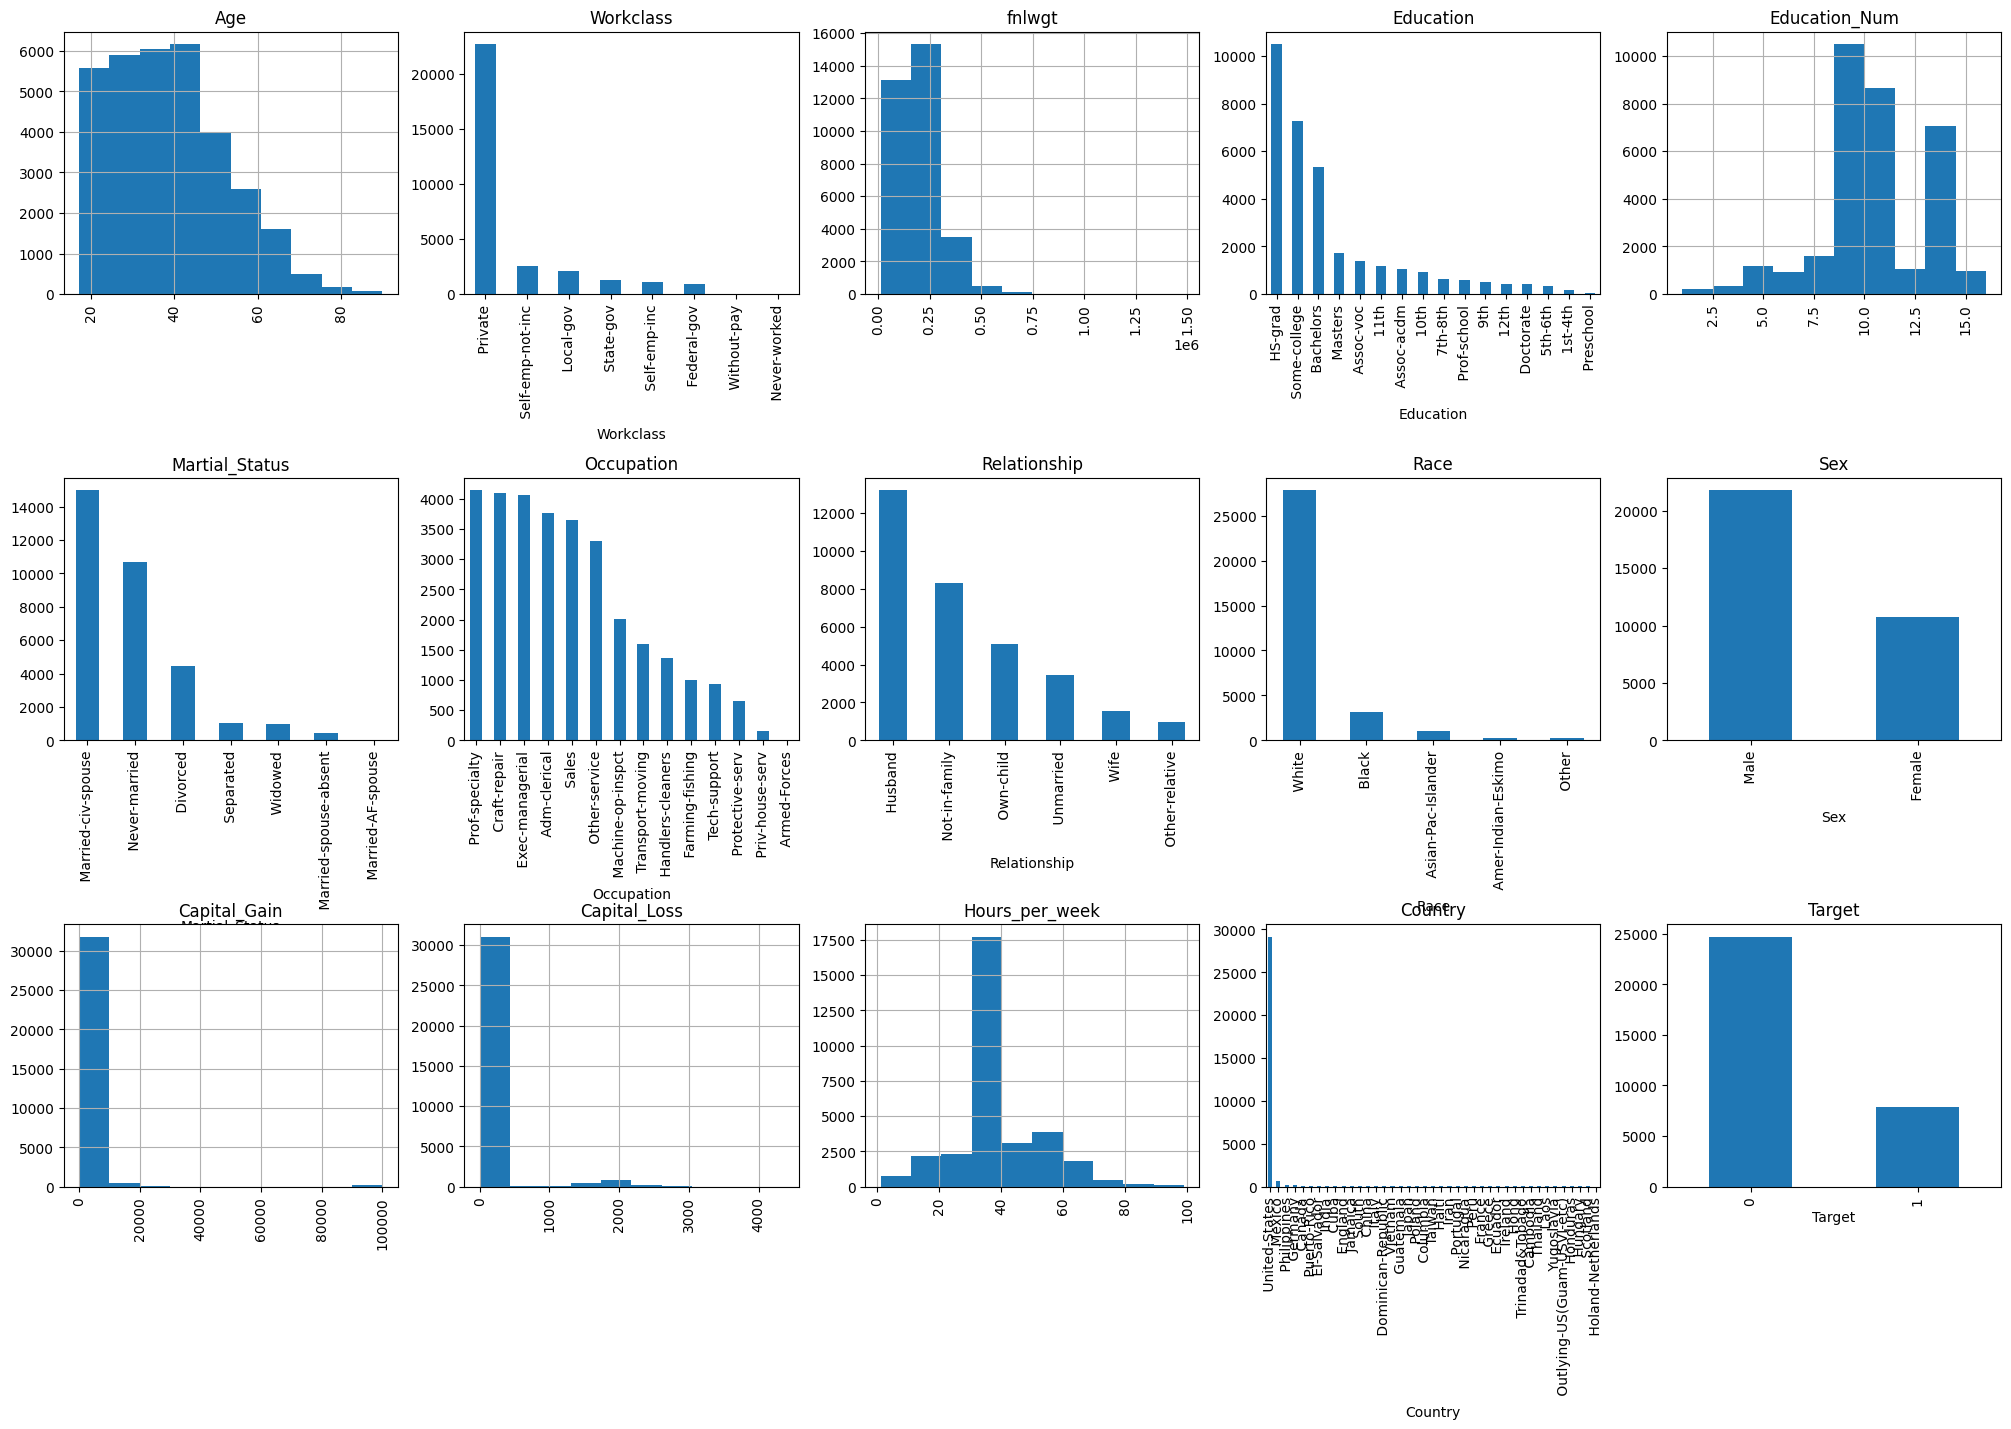

In [24]:
fig = plt.figure(figsize=(25,15))

cols = 5

rows = int(data_train.shape[1]/cols) # .shape returns a tuple (rows, columns)

for i, column in enumerate(data_train.columns): # enumerate adds a index number to columns and i represents index number
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.set_title(column)
    if data_train.dtypes[column] == object:
        data_train[column].value_counts().plot(kind="bar", axes=ax)
    else:
        data_train[column].hist(axes=ax)
        plt.xticks(rotation="vertical")

    plt.subplots_adjust(hspace=0.7, wspace=0.2)

In [25]:
data_train.dtypes

Age                int64
Workclass         object
fnlwgt             int64
Education         object
Education_Num      int64
Martial_Status    object
Occupation        object
Relationship      object
Race              object
Sex               object
Capital_Gain       int64
Capital_Loss       int64
Hours_per_week     int64
Country           object
Target            object
dtype: object

In [26]:
data_test.dtypes

Age                object
Workclass          object
fnlwgt            float64
Education          object
Education_Num     float64
Martial_Status     object
Occupation         object
Relationship       object
Race               object
Sex                object
Capital_Gain      float64
Capital_Loss      float64
Hours_per_week    float64
Country            object
Target             object
dtype: object

In [27]:
data_test["Age"] = data_test["Age"].astype(int)

data_test["fnlwgt"] = data_test["fnlwgt"].astype(int)
data_test["Education_Num"] = data_test["Education_Num"].astype(int)
data_test["Capital_Gain"] = data_test["Capital_Gain"].astype(int)
data_test["Capital_Loss"] = data_test["Capital_Loss"].astype(int)
data_test["Hours_per_week"] = data_test["Hours_per_week"].astype(int)

In [28]:
y_train = data_train.pop('Target')
y_test = data_test.pop('Target')

In [30]:
# Fill in missing data for continuous features with their median values, for categorical features
#  with their mode.

# choose categorical and continuous feature from data

categorical_columns = [
    c for c in data_train.columns if data_train[c].dtype.name == "object"
]

numerical_columns = [
    c for c in data_train.columns if data_train[c].dtype.name != "object"
]

print("categorical_columns:", categorical_columns)
print("numerical_columns:", numerical_columns)

categorical_columns: ['Workclass', 'Education', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']
numerical_columns: ['Age', 'fnlwgt', 'Education_Num', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week']


In [31]:
# we can see some missing infos

data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education_Num   32561 non-null  int64 
 5   Martial_Status  32561 non-null  object
 6   Occupation      30718 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital_Gain    32561 non-null  int64 
 11  Capital_Loss    32561 non-null  int64 
 12  Hours_per_week  32561 non-null  int64 
 13  Country         31978 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.5+ MB


In [32]:
# fill the missing data

for c in categorical_columns:
    data_train[c] = data_train[c].fillna(data_train[c].mode()[0])
    data_test[c] = data_test[c].fillna(data_train[c].mode()[0])

for c in numerical_columns:
    data_train[c] = data_train[c].fillna(data_train[c].median())
    data_test[c] = data_test[c].fillna(data_train[c].median())

# no more missing values
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education_Num   32561 non-null  int64 
 5   Martial_Status  32561 non-null  object
 6   Occupation      32561 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital_Gain    32561 non-null  int64 
 11  Capital_Loss    32561 non-null  int64 
 12  Hours_per_week  32561 non-null  int64 
 13  Country         32561 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.5+ MB


We’ll dummy code some categorical features: Workclass, Education, Martial_Status, Occupation, Relationship, Race, Sex, Country. It can be done via pandas method get_dummies

In [33]:
data_train = pd.concat(
    [data_train[numerical_columns], pd.get_dummies(data_train[categorical_columns])],
    axis=1,
)

data_test = pd.concat(
    [data_test[numerical_columns], pd.get_dummies(data_test[categorical_columns])],
    axis=1,
)

In [34]:
set(data_train.columns) - set(data_test.columns)

{'Country_ Holand-Netherlands'}

In [35]:
data_train.shape, data_test.shape

((32561, 105), (16281, 104))

There is no Holland in the test data. Create new zero-valued feature.

In [36]:
data_test["Country_ Holand-Netherlands"] = 0

set(data_train.columns) - set(data_test.columns)

set()

In [37]:
data_train.head(2)

,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_per_week,Workclass_ Federal-gov,Workclass_ Local-gov,Workclass_ Never-worked,Workclass_ Private,...,Country_ Portugal,Country_ Puerto-Rico,Country_ Scotland,Country_ South,Country_ Taiwan,Country_ Thailand,Country_ Trinadad&Tobago,Country_ United-States,Country_ Vietnam,Country_ Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [38]:
data_test.head(2)

,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_per_week,Workclass_ Federal-gov,Workclass_ Local-gov,Workclass_ Never-worked,Workclass_ Private,...,Country_ Puerto-Rico,Country_ Scotland,Country_ South,Country_ Taiwan,Country_ Thailand,Country_ Trinadad&Tobago,Country_ United-States,Country_ Vietnam,Country_ Yugoslavia,Country_ Holand-Netherlands
1,25,226802,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,True,False,False,0
2,38,89814,9,0,0,50,False,False,False,True,...,False,False,False,False,False,False,True,False,False,0


In [39]:
X_train = data_train
X_test = data_test